# XWorld — Dataset 8: ECG Heartbeat Segments (UCR)

Downloads ECGFiveDays from the UCR Time Series archive — 884 heartbeat segments.

**Expected**: Should NOT land in Cluster 1. ECG is fast and oscillatory — should cluster with keeling_seasonal or form its own cluster.

In [9]:
import requests
import zipfile
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

RAW_DIR = Path('../data/raw')
PROCESSED_DIR = Path('../data/processed')
print('Imports OK')

Imports OK


In [11]:
import urllib.request
import shutil

dest_zip = RAW_DIR / 'ECGFiveDays.zip'
dest_dir = RAW_DIR / 'ECGFiveDays'

if not dest_dir.exists() or not list(dest_dir.rglob('*.ts')):
    # Clean up any empty/partial directory from a previous failed attempt
    if dest_dir.exists():
        shutil.rmtree(dest_dir)

    print('Downloading ECGFiveDays...')
    urls = [
        'https://www.timeseriesclassification.com/aeon-toolkit/ECGFiveDays.zip',
        'https://www.timeseriesclassification.com/Downloads/ECGFiveDays.zip',
    ]
    downloaded = False
    for url in urls:
        try:
            req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})
            with urllib.request.urlopen(req, timeout=60) as resp:
                data = resp.read()
            dest_zip.write_bytes(data)
            # Validate it's actually a zip
            import zipfile
            if zipfile.is_zipfile(dest_zip):
                dest_dir.mkdir(exist_ok=True)
                with zipfile.ZipFile(dest_zip, 'r') as zf:
                    zf.extractall(dest_dir)
                print(f'Extracted to {dest_dir}')
                downloaded = True
                break
            else:
                print(f'  {url}: response was not a valid zip (got HTML?)')
                dest_zip.unlink(missing_ok=True)
        except Exception as e:
            print(f'  {url} failed: {e}')

    if not downloaded:
        print('ERROR: all download attempts failed.')
else:
    print(f'Already exists: {dest_dir}')

ts_files = list(dest_dir.rglob('*.ts')) if dest_dir.exists() else []
print(f'Found .ts files: {[f.name for f in ts_files]}')

Already exists: ../data/raw/ECGFiveDays
Found .ts files: ['ECGFiveDays_TRAIN.ts', 'ECGFiveDays_TEST.ts']


In [12]:
def parse_ts_file(path):
    series_list, labels = [], []
    in_data = False
    with open(path, 'r') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            if line.lower() == '@data':
                in_data = True
                continue
            if in_data and not line.startswith('@'):
                if ':' in line:
                    data_part, label = line.rsplit(':', 1)
                    values = [float(x) for x in data_part.split(',') if x.strip()]
                else:
                    parts = line.split()
                    values = [float(x) for x in parts[:-1]]
                    label = parts[-1]
                if values:
                    series_list.append(np.array(values))
                    labels.append(label.strip())
    return series_list, labels

all_series, all_labels = [], []
for ts_file in ts_files:
    s, l = parse_ts_file(ts_file)
    all_series.extend(s)
    all_labels.extend(l)
    print(f'{ts_file.name}: {len(s)} series')

print(f'Total: {len(all_series)} series, length {len(all_series[0]) if all_series else 0} pts')

ECGFiveDays_TRAIN.ts: 23 series
ECGFiveDays_TEST.ts: 861 series
Total: 884 series, length 136 pts


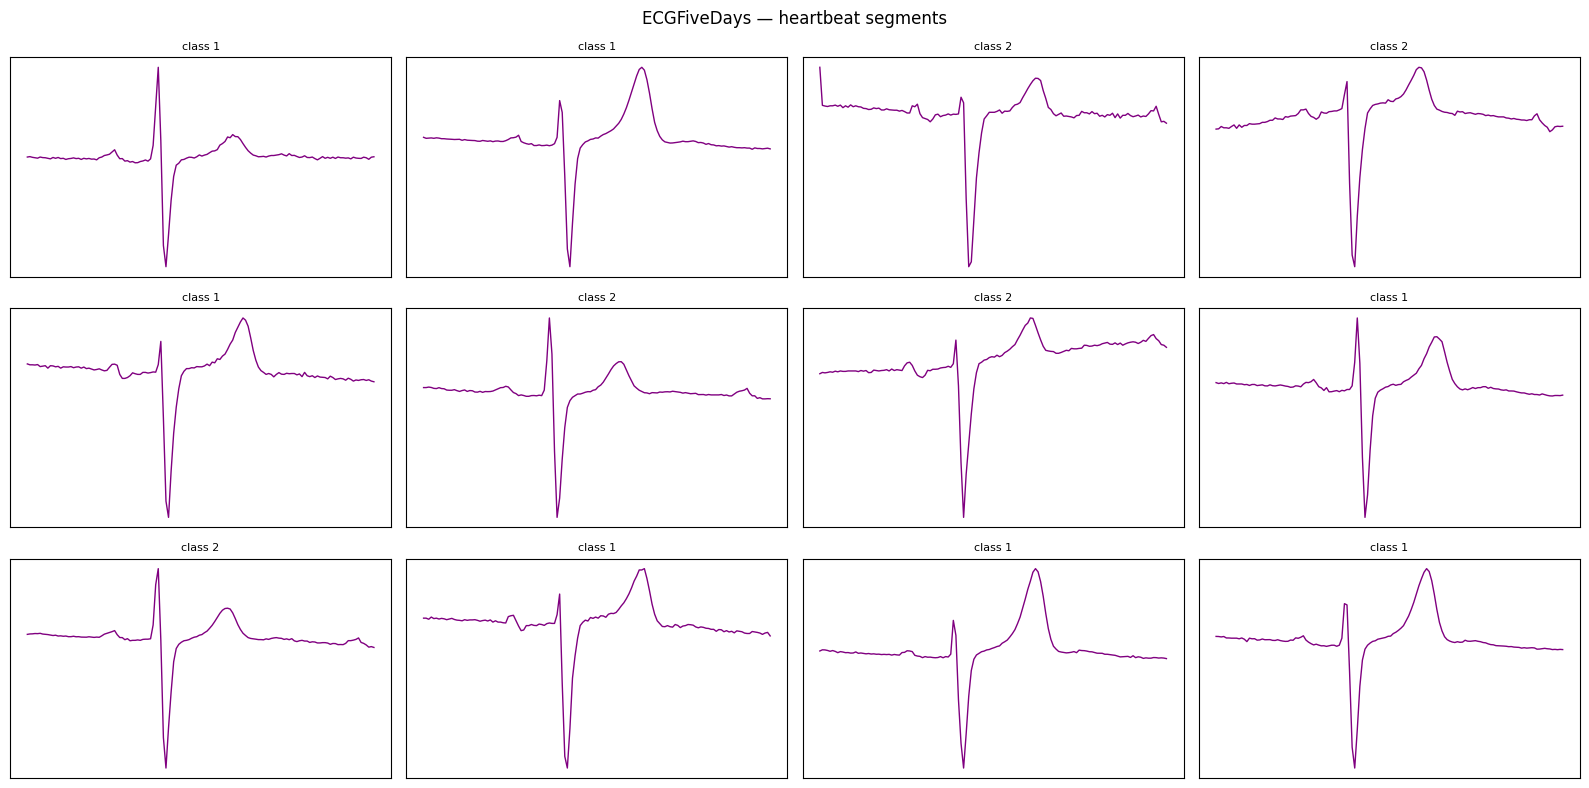

In [13]:
n_show = min(12, len(all_series))
fig, axes = plt.subplots(3, 4, figsize=(16, 8))
axes = axes.flatten()
for i in range(n_show):
    axes[i].plot(all_series[i], color='purple', linewidth=1.0)
    axes[i].set_title(f'class {all_labels[i]}', fontsize=8)
    axes[i].set_xticks([])
    axes[i].set_yticks([])
for j in range(n_show, len(axes)):
    axes[j].axis('off')
plt.suptitle('ECGFiveDays — heartbeat segments', fontsize=12)
plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'ecg_raw_sample.png', dpi=120, bbox_inches='tight')
plt.show()

In [14]:
def zscore_normalize(s):
    std = s.std()
    return (s - s.mean()) / std if std > 0 else s - s.mean()

def extract_features(series):
    n = len(series)
    t = np.arange(n)
    lag1 = np.corrcoef(series[:-1], series[1:])[0, 1] if n > 2 else 0.0
    zc = np.sum(np.diff(np.sign(series)) != 0) / n
    slope = stats.linregress(t, series).slope
    return {
        'mean': series.mean(), 'std': series.std(),
        'skewness': stats.skew(series), 'kurtosis': stats.kurtosis(series),
        'lag1_autocorr': lag1, 'zero_crossings': zc, 'slope': slope,
    }

records = []
for i, (s, label) in enumerate(zip(all_series, all_labels)):
    feats = extract_features(zscore_normalize(s))
    feats['country'] = f'ecg_{i}_c{label}'
    feats['dataset'] = 'ecg'
    feats['n_points'] = len(s)
    records.append(feats)

df_features = pd.DataFrame(records)
out_path = PROCESSED_DIR / 'features_ecg.csv'
df_features.to_csv(out_path, index=False)
print(f'Saved {len(df_features)} rows to {out_path}')

feature_cols = ['skewness', 'kurtosis', 'lag1_autocorr', 'zero_crossings', 'slope']
print('\nECG feature summary (watch zero_crossings — should be higher than other datasets):')
print(df_features[feature_cols].describe().round(3))

Saved 884 rows to ../data/processed/features_ecg.csv

ECG feature summary (watch zero_crossings — should be higher than other datasets):
       skewness  kurtosis  lag1_autocorr  zero_crossings    slope
count   884.000   884.000        884.000         884.000  884.000
mean     -2.342    15.165          0.860           0.078    0.002
std       1.137     4.405          0.048           0.036    0.003
min      -4.441     6.091          0.701           0.022   -0.009
25%      -3.245    11.651          0.835           0.051   -0.000
50%      -2.411    15.837          0.872           0.074    0.002
75%      -1.508    18.816          0.892           0.096    0.003
max       0.141    24.783          0.931           0.287    0.014
